In [1]:
import common_imports
from common_imports import *


In [2]:
import glob

# Paths from common_imports are absolute (under the Part_2 project folder).
anchor = sorted(glob.glob(os.path.join(ANC_PATH, "*.jpg")))[:3000]
positive = sorted(glob.glob(os.path.join(POS_PATH, "*.jpg")))[:3000]
negative = sorted(glob.glob(os.path.join(NEG_PATH, "*.jpg")))[:3000]

print(f"anchor={len(anchor)}, positive={len(positive)}, negative={len(negative)}")
if anchor:
    print("example:", anchor[0])


anchor=34, positive=210, negative=3000
example: /Users/igorhebda/Desktop/HTW-Bio/Part_2/data/anchor/25a1ab9a-35c0-11f1-a9c0-9ab6d786755e.jpg


In [3]:
def preprocess(file_path):
    """Load image from disk → float32 tensor [3, 100, 100], RGB, values in [0, 1].

    (TensorFlow used HWC; PyTorch Conv2d expects NCHW, so we store CHW here.)
    """
    img_bgr = cv2.imread(str(file_path))
    if img_bgr is None:
        raise ValueError(f"Could not read image: {file_path!r}")
    img_bgr = cv2.resize(img_bgr, (100, 100))
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(rgb).permute(2, 0, 1).contiguous().float() / 255.0


In [4]:
import glob

_paths = sorted(glob.glob(os.path.join(ANC_PATH, "*.jpg")))
if not _paths:
    raise FileNotFoundError(f"No .jpg files in {ANC_PATH!r}")
img = preprocess(_paths[0])
img.max().item()


1.0

In [5]:
# (anchor, positive) → 1.0  |  (anchor, negative) → 0.0
# Like tf.data: list of (path_a, path_b, label) triples.
positives = [(a, p, 1.0) for a, p in zip(anchor, positive)]
negatives = [(a, n, 0.0) for a, n in zip(anchor, negative)]
data = positives + negatives

if not data:
    raise ValueError(
        "No pairs: add images under data/positive and data/negative (and anchor), then re-run the glob cell."
    )

samples = iter(data)
example = next(samples)
example


('/Users/igorhebda/Desktop/HTW-Bio/Part_2/data/anchor/25a1ab9a-35c0-11f1-a9c0-9ab6d786755e.jpg',
 '/Users/igorhebda/Desktop/HTW-Bio/Part_2/data/positive/1f3b9482-35c0-11f1-a9c0-9ab6d786755e.jpg',
 1.0)

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

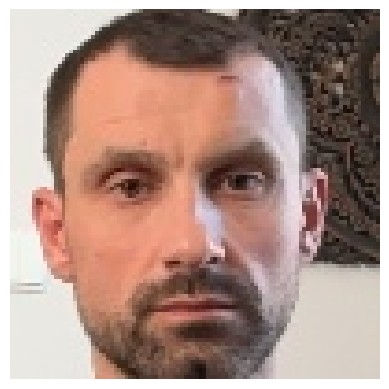

In [6]:
def preprocess_twin(input_img, validation_img, label):
    return preprocess(input_img), preprocess(validation_img), label


def _chw_for_imshow(t):
    """Tensor [C,H,W] RGB in [0,1] → HWC numpy array for matplotlib."""
    return t.detach().cpu().permute(1, 2, 0).numpy().clip(0, 1)


res = preprocess_twin(*example)
plt.imshow(_chw_for_imshow(res[1]))
plt.axis("off")


In [7]:
res[2]


1.0

In [8]:
# PyTorch Dataset + DataLoader (`data` is a list of path triples).
from torch.utils.data import Dataset, DataLoader


class SiameseDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = list(pairs)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        a, b, lab = self.pairs[idx]
        x1, x2, _ = preprocess_twin(a, b, lab)
        return x1, x2, torch.tensor(lab, dtype=torch.float32)


if not data:
    raise ValueError("`data` is empty — build anchor/positive/negative pairs in the previous cell.")

pairs = data[:]
random.shuffle(pairs)
n_train = round(len(pairs) * 0.7)
train_pairs = pairs[:n_train]
test_pairs = pairs[n_train:]

# Apple Metal (MPS): pin_memory only helps CUDA — keep False here.
train_data = DataLoader(
    SiameseDataset(train_pairs),
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)
test_data = DataLoader(
    SiameseDataset(test_pairs),
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print(f"train batches: {len(train_data)}, test batches: {len(test_data)} (samples: {len(train_pairs)} / {len(test_pairs)})")


train batches: 3, test batches: 2 (samples: 48 / 20)


In [9]:
class EmbeddingNet(nn.Module):
    """CNN embedding like the Keras tutorial — input NCHW [N, 3, 100, 100]."""

    def __init__(self):
        super().__init__()
        self.embedding = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=10),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
            nn.Conv2d(64, 128, kernel_size=7),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
            nn.Conv2d(128, 128, kernel_size=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
            nn.Conv2d(128, 256, kernel_size=4),
            nn.ReLU(inplace=True),
            nn.Flatten(),
            nn.Linear(9216, 4096),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.embedding(x)


def make_embedding():
    return EmbeddingNet()


from torchinfo import summary

embedding = make_embedding()
mod = embedding

# Table like Keras `model.summary()` — shapes are NCHW [batch, channels, H, W].
summary(
    embedding.embedding,
    input_size=(1, 3, 100, 100),
    col_names=("output_size", "num_params"),
    col_width=24,
    verbose=1,
)


Layer (type:depth-idx)                   Output Shape             Param #
Sequential                               [1, 4096]                --
├─Conv2d: 1-1                            [1, 64, 91, 91]          19,264
├─ReLU: 1-2                              [1, 64, 91, 91]          --
├─MaxPool2d: 1-3                         [1, 64, 46, 46]          --
├─Conv2d: 1-4                            [1, 128, 40, 40]         401,536
├─ReLU: 1-5                              [1, 128, 40, 40]         --
├─MaxPool2d: 1-6                         [1, 128, 20, 20]         --
├─Conv2d: 1-7                            [1, 128, 17, 17]         262,272
├─ReLU: 1-8                              [1, 128, 17, 17]         --
├─MaxPool2d: 1-9                         [1, 128, 9, 9]           --
├─Conv2d: 1-10                           [1, 256, 6, 6]           524,544
├─ReLU: 1-11                             [1, 256, 6, 6]           --
├─Flatten: 1-12                          [1, 9216]                --
├─Linear: 

Layer (type:depth-idx)                   Output Shape             Param #
Sequential                               [1, 4096]                --
├─Conv2d: 1-1                            [1, 64, 91, 91]          19,264
├─ReLU: 1-2                              [1, 64, 91, 91]          --
├─MaxPool2d: 1-3                         [1, 64, 46, 46]          --
├─Conv2d: 1-4                            [1, 128, 40, 40]         401,536
├─ReLU: 1-5                              [1, 128, 40, 40]         --
├─MaxPool2d: 1-6                         [1, 128, 20, 20]         --
├─Conv2d: 1-7                            [1, 128, 17, 17]         262,272
├─ReLU: 1-8                              [1, 128, 17, 17]         --
├─MaxPool2d: 1-9                         [1, 128, 9, 9]           --
├─Conv2d: 1-10                           [1, 256, 6, 6]           524,544
├─ReLU: 1-11                             [1, 256, 6, 6]           --
├─Flatten: 1-12                          [1, 9216]                --
├─Linear: 

In [10]:
# Siamese L1 distance (same idea as Keras: |a - b|).
class L1Dist(nn.Module):
    def forward(self, input_embedding, validation_embedding):
        return torch.abs(input_embedding - validation_embedding)


l1 = L1Dist()

# Quick check: two embeddings (run the `embedding` cell above first).
with torch.no_grad():
    x_a = torch.randn(1, 3, 100, 100)
    x_v = torch.randn(1, 3, 100, 100)
    anchor_embedding = embedding(x_a)
    validation_embedding = embedding(x_v)
    l1_out = l1(anchor_embedding, validation_embedding)

print("L1 shape:", tuple(l1_out.shape), "dtype:", l1_out.dtype)


L1 shape: (1, 4096) dtype: torch.float32


In [11]:
class SiameseNetwork(nn.Module):
    """Two branches share `embedding`, then L1, Linear(4096→1), sigmoid."""

    def __init__(self, embedding_net: nn.Module):
        super().__init__()
        self.embedding = embedding_net
        self.l1 = L1Dist()
        self.classifier = nn.Linear(4096, 1)

    def forward(self, input_img, validation_img):
        inp_e = self.embedding(input_img)
        val_e = self.embedding(validation_img)
        distances = self.l1(inp_e, val_e)
        return torch.sigmoid(self.classifier(distances))


siamese_network = SiameseNetwork(embedding)

from torchinfo import summary

summary(
    siamese_network,
    input_size=[(1, 3, 100, 100), (1, 3, 100, 100)],
    col_names=("output_size", "num_params"),
    col_width=24,
    verbose=1,
)

# Do not call .to(device) here: another SiameseNetwork reuses the same `embedding`.
# Keep torchinfo summary on CPU; call .to(device) in the siamese_model cell.


Layer (type:depth-idx)                   Output Shape             Param #
SiameseNetwork                           [1, 1]                   --
├─EmbeddingNet: 1-1                      [1, 4096]                --
│    └─Sequential: 2-1                   [1, 4096]                --
│    │    └─Conv2d: 3-1                  [1, 64, 91, 91]          19,264
│    │    └─ReLU: 3-2                    [1, 64, 91, 91]          --
│    │    └─MaxPool2d: 3-3               [1, 64, 46, 46]          --
│    │    └─Conv2d: 3-4                  [1, 128, 40, 40]         401,536
│    │    └─ReLU: 3-5                    [1, 128, 40, 40]         --
│    │    └─MaxPool2d: 3-6               [1, 128, 20, 20]         --
│    │    └─Conv2d: 3-7                  [1, 128, 17, 17]         262,272
│    │    └─ReLU: 3-8                    [1, 128, 17, 17]         --
│    │    └─MaxPool2d: 3-9               [1, 128, 9, 9]           --
│    │    └─Conv2d: 3-10                 [1, 256, 6, 6]           524,544
│    │    

Layer (type:depth-idx)                   Output Shape             Param #
SiameseNetwork                           [1, 1]                   --
├─EmbeddingNet: 1-1                      [1, 4096]                --
│    └─Sequential: 2-1                   [1, 4096]                --
│    │    └─Conv2d: 3-1                  [1, 64, 91, 91]          19,264
│    │    └─ReLU: 3-2                    [1, 64, 91, 91]          --
│    │    └─MaxPool2d: 3-3               [1, 64, 46, 46]          --
│    │    └─Conv2d: 3-4                  [1, 128, 40, 40]         401,536
│    │    └─ReLU: 3-5                    [1, 128, 40, 40]         --
│    │    └─MaxPool2d: 3-6               [1, 128, 20, 20]         --
│    │    └─Conv2d: 3-7                  [1, 128, 17, 17]         262,272
│    │    └─ReLU: 3-8                    [1, 128, 17, 17]         --
│    │    └─MaxPool2d: 3-9               [1, 128, 9, 9]           --
│    │    └─Conv2d: 3-10                 [1, 256, 6, 6]           524,544
│    │    

In [12]:
def make_siamese_model(embedding_net=None):
    """Factory like Keras — uses the global `embedding` by default (shared weights)."""
    net = embedding if embedding_net is None else embedding_net
    return SiameseNetwork(net)


siamese_model = make_siamese_model()

from torchinfo import summary

summary(
    siamese_model,
    input_size=[(1, 3, 100, 100), (1, 3, 100, 100)],
    col_names=("output_size", "num_params"),
    col_width=24,
    verbose=1,
)

siamese_model = siamese_model.to(device)


Layer (type:depth-idx)                   Output Shape             Param #
SiameseNetwork                           [1, 1]                   --
├─EmbeddingNet: 1-1                      [1, 4096]                --
│    └─Sequential: 2-1                   [1, 4096]                --
│    │    └─Conv2d: 3-1                  [1, 64, 91, 91]          19,264
│    │    └─ReLU: 3-2                    [1, 64, 91, 91]          --
│    │    └─MaxPool2d: 3-3               [1, 64, 46, 46]          --
│    │    └─Conv2d: 3-4                  [1, 128, 40, 40]         401,536
│    │    └─ReLU: 3-5                    [1, 128, 40, 40]         --
│    │    └─MaxPool2d: 3-6               [1, 128, 20, 20]         --
│    │    └─Conv2d: 3-7                  [1, 128, 17, 17]         262,272
│    │    └─ReLU: 3-8                    [1, 128, 17, 17]         --
│    │    └─MaxPool2d: 3-9               [1, 128, 9, 9]           --
│    │    └─Conv2d: 3-10                 [1, 256, 6, 6]           524,544
│    │    

In [13]:
binary_cross_loss = nn.BCELoss()
opt = torch.optim.Adam(siamese_model.parameters(), lr=1e-4)

checkpoint_dir = os.path.abspath("./training_checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "ckpt.pt")

# PyTorch checkpoint during training could look like:
# torch.save(
#     {"model": siamese_model.state_dict(), "optimizer": opt.state_dict()},
#     checkpoint_path,
# )

batch_1 = next(iter(train_data))
X = batch_1[:2]
y = batch_1[2]
y


tensor([1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1.])

In [14]:
def train_step(batch):
    siamese_model.train()
    opt.zero_grad()

    x1, x2 = batch[:2]
    y = batch[2]

    x1 = x1.to(device)
    x2 = x2.to(device)
    y = y.to(device).float()
    if y.ndim == 1:
        y = y.unsqueeze(1)

    yhat = siamese_model(x1, x2)
    # nn.BCELoss(input, target) — argument order differs from Keras (y_true, y_pred).
    loss = binary_cross_loss(yhat, y)
    loss.backward()
    opt.step()

    print(loss.item())
    return loss.detach()


In [15]:
def train(data, EPOCHS):
    siamese_model.to(device)
    for epoch in range(1, EPOCHS + 1):
        print(f"\n Epoch {epoch}/{EPOCHS}")
        n_batches = len(data)
        tp = fp = fn = 0.0
        last_loss = None

        for idx, batch in enumerate(data, start=1):
            last_loss = train_step(batch)

            siamese_model.eval()
            with torch.no_grad():
                x1, x2 = batch[:2]
                x1 = x1.to(device)
                x2 = x2.to(device)
                yhat = siamese_model(x1, x2)
                y = batch[2].to(device).float()
                if y.ndim == 1:
                    y = y.unsqueeze(1)
                pred = (yhat >= 0.5).float()
                tp += (pred * y).sum().item()
                fp += (pred * (1.0 - y)).sum().item()
                fn += ((1.0 - pred) * y).sum().item()
            siamese_model.train()

            print(f"\r  {idx}/{n_batches}", end="", flush=True)

        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        print()
        print(last_loss.item(), precision, recall)

        if epoch % 10 == 0:
            torch.save(
                {"model": siamese_model.state_dict(), "optimizer": opt.state_dict()},
                checkpoint_path,
            )


In [16]:
EPOCHS = 50
train(train_data, EPOCHS)



 Epoch 1/50
0.6946461796760559
  1/30.6922649145126343
  2/30.6903584003448486
  3/3
0.6903584003448486 0.0 0.0

 Epoch 2/50
0.6888688206672668
  1/30.6795299053192139
  2/30.6624642610549927
  3/3
0.6624642610549927 0.9999999937499999 0.5925925903978052

 Epoch 3/50
0.6413145065307617
  1/30.6436508893966675
  2/30.6251606941223145
  3/3
0.6251606941223145 0.9999999952380952 0.7777777748971193

 Epoch 4/50
0.5973822474479675
  1/30.6039222478866577
  2/30.4116380214691162
  3/3
0.4116380214691162 0.9999999956521739 0.8518518486968449

 Epoch 5/50
0.4356244206428528
  1/30.4519088864326477
  2/30.5185391306877136
  3/3
0.5185391306877136 0.9310344795481569 0.9999999962962962

 Epoch 6/50
0.35380762815475464
  1/30.4400279223918915
  2/30.39007240533828735
  3/3
0.39007240533828735 0.9310344795481569 0.9999999962962962

 Epoch 7/50
0.3092549443244934
  1/30.2905524969100952
  2/30.29541248083114624
  3/3
0.29541248083114624 0.9310344795481569 0.9999999962962962

 Epoch 8/50
0.281334459

In [17]:
# One batch from test_data (PyTorch DataLoader).
test_input, test_val, y_true = next(iter(test_data))

siamese_model.eval()
with torch.no_grad():
    y_hat = siamese_model(
        test_input.to(device),
        test_val.to(device),
    )

# Threshold 0.5 on sigmoid outputs (Keras-style predict + thresholding).
y_pred = [1 if p > 0.5 else 0 for p in y_hat.squeeze(-1).cpu().numpy()]
y_pred, y_true


([0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0],
 tensor([0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.]))

In [18]:
def _confusion_update(tp, fp, fn, y_true, y_hat, threshold=0.5):
    """Recall and precision at probability threshold 0.5 (Keras-style)."""
    y = y_true.float()
    if y.ndim == 1:
        y = y.unsqueeze(1)
    pred = (y_hat >= threshold).float()
    tp += (pred * y).sum().item()
    fp += (pred * (1.0 - y)).sum().item()
    fn += ((1.0 - pred) * y).sum().item()
    return tp, fp, fn


# One batch — uses y_true and y_hat from the previous cell.
tp = fp = fn = 0.0
tp, fp, fn = _confusion_update(tp, fp, fn, y_true.to(device), y_hat)
recall_b = tp / (tp + fn + 1e-7)
precision_b = tp / (tp + fp + 1e-7)
print(recall_b, precision_b)

# Full test set via DataLoader.
tp = fp = fn = 0.0
siamese_model.eval()
with torch.no_grad():
    for test_input, test_val, y_batch in test_data:
        yhat = siamese_model(test_input.to(device), test_val.to(device))
        tp, fp, fn = _confusion_update(tp, fp, fn, y_batch.to(device), yhat)

recall_all = tp / (tp + fn + 1e-7)
precision_all = tp / (tp + fp + 1e-7)
print(recall_all, precision_all)


0.9999999833333336 0.6666666592592594
0.9999999857142858 0.6999999930000002


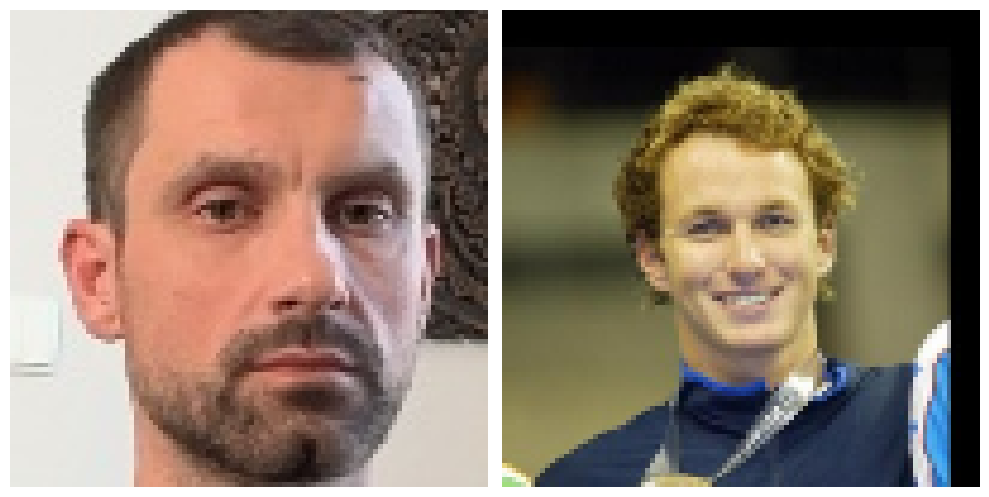

In [19]:
plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(_chw_for_imshow(test_input[0]))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(_chw_for_imshow(test_val[0]))
plt.axis("off")

plt.tight_layout()
plt.show()


In [20]:
# Save / load weights (PyTorch state_dict, not Keras .h5).
weights_path = "siamesemodelv2.pt"

torch.save(siamese_model.state_dict(), weights_path)

siamese_model = make_siamese_model()
siamese_model.load_state_dict(torch.load(weights_path, map_location="cpu"))

from torchinfo import summary

summary(
    siamese_model,
    input_size=[(1, 3, 100, 100), (1, 3, 100, 100)],
    col_names=("output_size", "num_params"),
    col_width=24,
    verbose=1,
)

siamese_model = siamese_model.to(device)
siamese_model.eval()

with torch.no_grad():
    y_reload = siamese_model(test_input.to(device), test_val.to(device))
y_reload


Layer (type:depth-idx)                   Output Shape             Param #
SiameseNetwork                           [1, 1]                   --
├─EmbeddingNet: 1-1                      [1, 4096]                --
│    └─Sequential: 2-1                   [1, 4096]                --
│    │    └─Conv2d: 3-1                  [1, 64, 91, 91]          19,264
│    │    └─ReLU: 3-2                    [1, 64, 91, 91]          --
│    │    └─MaxPool2d: 3-3               [1, 64, 46, 46]          --
│    │    └─Conv2d: 3-4                  [1, 128, 40, 40]         401,536
│    │    └─ReLU: 3-5                    [1, 128, 40, 40]         --
│    │    └─MaxPool2d: 3-6               [1, 128, 20, 20]         --
│    │    └─Conv2d: 3-7                  [1, 128, 17, 17]         262,272
│    │    └─ReLU: 3-8                    [1, 128, 17, 17]         --
│    │    └─MaxPool2d: 3-9               [1, 128, 9, 9]           --
│    │    └─Conv2d: 3-10                 [1, 256, 6, 6]           524,544
│    │    

tensor([[3.6531e-04],
        [7.6234e-05],
        [9.9970e-01],
        [4.3542e-06]], device='mps:0')

In [21]:
# App paths under Part_2 (same root as ANC_PATH in common_imports).
_PART_2_ROOT = os.path.dirname(os.path.dirname(ANC_PATH))
APP_DATA = os.path.join(_PART_2_ROOT, "application_data")
VERIF_DIR = os.path.join(APP_DATA, "verification_images")
INPUT_IMAGE_PATH = os.path.join(APP_DATA, "input_image", "input_image.jpg")

os.makedirs(os.path.dirname(INPUT_IMAGE_PATH), exist_ok=True)
os.makedirs(VERIF_DIR, exist_ok=True)

os.listdir(VERIF_DIR)
INPUT_IMAGE_PATH


def verify(model, detection_threshold, verification_threshold):
    """Compare input_image to each file in verification_images (Siamese, PyTorch)."""
    os.makedirs(VERIF_DIR, exist_ok=True)
    if not os.path.isfile(INPUT_IMAGE_PATH):
        raise FileNotFoundError(f"Missing file: {INPUT_IMAGE_PATH!r}")
    results = []
    names = sorted(f for f in os.listdir(VERIF_DIR) if f.lower().endswith(common_imports.GALLERY_EXTS))
    model.eval()
    input_t = preprocess(INPUT_IMAGE_PATH).unsqueeze(0).to(device)
    with torch.no_grad():
        for image in names:
            val_t = preprocess(os.path.join(VERIF_DIR, image)).unsqueeze(0).to(device)
            out = model(input_t, val_t)
            results.append(float(out.squeeze().cpu()))

    n = len(names)
    arr = np.array(results, dtype=np.float64)
    detection = int(np.sum(arr > detection_threshold))
    verification = detection / max(n, 1)
    verified = verification > verification_threshold
    return results, verified


In [22]:
# --- Center crop + optional mirror (same idea as 2.ipynb) ---
# OpenCV window: click for focus; V = save + verify; Q = quit.

ROI = 250
OFFSET_X = 0
OFFSET_Y = 0
MIRROR_HORIZONTAL = True


def center_square_roi(frame_bgr, side: int, off_x: int = 0, off_y: int = 0):
    """Square crop from the frame center (same as 2.ipynb)."""
    h, w = frame_bgr.shape[:2]
    if h >= side and w >= side:
        x0 = (w - side) // 2 + off_x
        y0 = (h - side) // 2 + off_y
        x0 = max(0, min(x0, w - side))
        y0 = max(0, min(y0, h - side))
        return frame_bgr[y0 : y0 + side, x0 : x0 + side, :]
    s = min(h, w)
    y0 = (h - s) // 2
    x0 = (w - s) // 2
    patch = frame_bgr[y0 : y0 + s, x0 : x0 + s, :]
    return cv2.resize(patch, (side, side))


print(
    "Verification window: click for focus, V = verify, Q = quit. "
    "ROI / OFFSET / MIRROR — same idea as in 2.ipynb."
)

_PART_2_ROOT = os.path.dirname(os.path.dirname(ANC_PATH))
_INPUT_DIR = os.path.join(_PART_2_ROOT, "application_data", "input_image")
os.makedirs(_INPUT_DIR, exist_ok=True)
INPUT_SAVE_PATH = os.path.join(_INPUT_DIR, "input_image.jpg")

print("Verification gallery — add .jpg / .jpeg / .png / .webp files here:")
print(" ", os.path.abspath(VERIF_DIR))

last_results = None
last_verified = None

cap = None
for cam_index in (0, 1, 2, 3, 4):
    c = cv2.VideoCapture(cam_index)
    if c.isOpened():
        ret, test = c.read()
        if ret and test is not None and test.size > 0:
            cap = c
            print(f"Camera: index {cam_index}")
            break
        c.release()

if cap is None or not cap.isOpened():
    print(
        "Could not open the camera (check System Settings → Privacy → Camera, or try another index)."
    )
else:
    # Warm-up reads: first frames are often empty or stale in the buffer (macOS / AVFoundation).
    # We avoid CAP_PROP_BUFFERSIZE; on some Macs it breaks a smooth preview stream.
    for _ in range(30):
        cap.read()

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret or frame is None:
                cv2.waitKey(5)
                continue

            if MIRROR_HORIZONTAL:
                frame = cv2.flip(frame, 1)

            roi = center_square_roi(frame, ROI, OFFSET_X, OFFSET_Y)
            # Draw overlay on a copy only; save a clean ROI (text would hurt verification).
            display = roi.copy()
            cv2.putText(
                display,
                "V=verify Q=quit",
                (4, 18),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
                cv2.LINE_AA,
            )

            cv2.imshow("Verification", display)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("v"):
                cv2.imwrite(INPUT_SAVE_PATH, roi)
                last_results, last_verified = verify(siamese_model, 0.5, 0.5)
                gallery = sorted(f for f in os.listdir(VERIF_DIR) if f.lower().endswith(common_imports.GALLERY_EXTS))
                print("verified:", last_verified, "— preview keeps running; Q = quit.")
                if not gallery:
                    print(
                        "  (no .jpg/.jpeg/.png/.webp in gallery — nothing to compare)"
                    )
                    _all = sorted(os.listdir(VERIF_DIR))
                    print("  Directory:", os.path.abspath(VERIF_DIR))
                    print(
                        "  Contents (all filenames):",
                        _all if _all else "(empty folder)",
                    )
                elif len(gallery) != len(last_results):
                    print("  WARNING: len(gallery)=", len(gallery), "len(scores)=", len(last_results))
                    print("  files:", gallery)
                    print("  scores:", last_results)
                else:
                    _scores = np.asarray(last_results, dtype=np.float64)
                    if _scores.size:
                        print(
                            f"  min = {_scores.min():.6f}, mean = {_scores.mean():.6f}, max = {_scores.max():.6f}"
                        )
            elif key == ord("q"):
                break
    finally:
        cap.release()

cv2.destroyAllWindows()

if last_results is None:
    print(
        "verify() did not run: focus the Verification window, then press V on the keyboard "
        "(not in the Jupyter cell)."
    )
else:
    _arr = np.asarray(last_results, dtype=np.float64)
    print("np.sum(results > 0.9) =", int(np.sum(_arr > 0.9)))
    if _arr.size == 0:
        print(
            "(empty scores — gallery had no .jpg/.jpeg/.png/.webp; "
            "copy images into the directory printed above)"
        )
    last_results


Verification window: click for focus, V = verify, Q = quit. ROI / OFFSET / MIRROR — same idea as in 2.ipynb.
Verification gallery — add .jpg / .jpeg / .png / .webp files here:
  /Users/igorhebda/Desktop/HTW-Bio/Part_2/application_data/verification_images
Camera: index 0
verified: True — preview keeps running; Q = quit.
  min = 0.974214, mean = 0.991834, max = 0.999950
verified: True — preview keeps running; Q = quit.
  min = 0.793862, mean = 0.907946, max = 0.998601
verified: True — preview keeps running; Q = quit.
  min = 0.989466, mean = 0.996480, max = 0.999981
verified: False — preview keeps running; Q = quit.
  min = 0.000006, mean = 0.002234, max = 0.030091
verified: False — preview keeps running; Q = quit.
  min = 0.134444, mean = 0.575697, max = 0.984776
verified: True — preview keeps running; Q = quit.
  min = 0.999127, mean = 0.999798, max = 0.999999
verified: True — preview keeps running; Q = quit.
  min = 0.993093, mean = 0.997863, max = 0.999985
verified: True — preview ke